# 머신러닝 소개와 문제 유형

## 실습 목표

| 번호 | 목표 | 핵심 코드 |
|:----:|------|----------|
| 1 | sklearn 기본 패턴 이해 | `fit()`, `predict()`, `score()` |
| 2 | 분류 문제 실습 | `DecisionTreeClassifier` |
| 3 | 회귀 문제 실습 | `LinearRegression` |
| 4 | 학습/테스트 분리 | `train_test_split` |

---

## 실습 흐름

```mermaid
flowchart LR
    subgraph 준비["1. 데이터 준비"]
        A[데이터 로드] --> B[특성/타겟 분리]
        B --> C[학습/테스트 분할]
    end
    
    subgraph 분류["2. 분류 실습"]
        D[모델 생성] --> E[fit 학습]
        E --> F[predict 예측]
        F --> G[score 평가]
    end
    
    subgraph 회귀["3. 회귀 실습"]
        H[모델 생성] --> I[fit 학습]
        I --> J[predict 예측]
        J --> K[score 평가]
    end
    
    준비 --> 분류 --> 회귀
```

## 실습 환경 설정

In [1]:
# 기본 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# sklearn 라이브러리
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, r2_score, mean_squared_error

# 시각화 설정
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')

print("라이브러리 로드 완료")
print(f"sklearn 버전: {__import__('sklearn').__version__}")

라이브러리 로드 완료
sklearn 버전: 1.8.0


## 11차시 복습: 왜 머신러닝인가?

### 선형 회귀의 한계 상기

11차시에서 우리는 선형 회귀의 한계를 발견했음:

| 한계 | 설명 |
|------|------|
| 낮은 설명력 | R² 값이 낮아 변동의 일부만 설명 |
| 비선형 관계 | $y = \beta_0 + \beta_1 x$ 형태로는 곡선 관계 포착 불가 |
| 분류 문제 | Pass/Fail 같은 범주 예측에 부적합 |

**해결책**: 머신러닝 알고리즘 도입

### 2.2 머신러닝의 핵심 아이디어

```
[전통적 방식]
  사람이 규칙 정의: if 온도 > 90: 불량

[머신러닝 방식]
  데이터가 규칙 학습: 모델이 스스로 "온도 > 87.3이면 불량 확률 72%" 발견
```

## 분류 실습: SECOM 반도체 데이터

**분류(Classification)**: 범주(카테고리)를 예측하는 문제

$$\text{출력: } y \in \{C_1, C_2, ..., C_k\}$$

**예시 질문**:
- "이 제품은 불량인가요?" → 불량(1) / 정상(0)
- "어떤 불량 유형인가요?" → 스크래치 / 오염 / 변형

In [2]:
# SECOM 반도체 제조 데이터 로드
secom_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.data"
labels_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom_labels.data"

# 센서 데이터
df_sensors = pd.read_csv(secom_url, sep=' ', header=None)
df_sensors.columns = [f'Sensor_{i}' for i in range(df_sensors.shape[1])]

# 레이블 (정답)
df_labels = pd.read_csv(labels_url, sep=' ', header=None, usecols=[0])
df_labels.columns = ['Pass_Fail']

# 병합
df_secom = pd.concat([df_sensors, df_labels], axis=1)

print("=" * 60)
print("SECOM 반도체 제조 데이터 로드 완료")
print("=" * 60)
print(f"데이터 크기: {df_secom.shape[0]:,}개 샘플, {df_secom.shape[1]:,}개 변수")
print(f"\n타겟 변수 분포:")
print(df_secom['Pass_Fail'].value_counts())
print(f"\n불량률: {(df_secom['Pass_Fail'] == 1).mean()*100:.2f}%")

SECOM 반도체 제조 데이터 로드 완료
데이터 크기: 1,567개 샘플, 591개 변수

타겟 변수 분포:
Pass_Fail
-1    1463
 1     104
Name: count, dtype: int64

불량률: 6.64%


### 데이터 전쳐리

In [3]:
# 센서 컬럼만 추출
sensor_cols = [col for col in df_secom.columns if col.startswith('Sensor_')]

# 결측 비율 50% 미만인 변수만 선택
missing_pct = df_secom[sensor_cols].isna().sum() / len(df_secom) * 100
cols_to_keep = missing_pct[missing_pct < 50].index.tolist()

# 분산이 0인 변수 제거
df_temp = df_secom[cols_to_keep].copy()
nonzero_var = df_temp.var() > 0
cols_to_keep = [col for col in cols_to_keep if nonzero_var[col]]

print(f"선택된 변수 수: {len(cols_to_keep)}개")

# 결측치 중앙값 대체
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(df_secom[cols_to_keep])
X_secom = pd.DataFrame(X_imputed, columns=cols_to_keep)

# 타겟 변수
y_secom = df_secom['Pass_Fail'].values

print(f"최종 데이터: X shape = {X_secom.shape}, y shape = {y_secom.shape}")

선택된 변수 수: 446개
최종 데이터: X shape = (1567, 446), y shape = (1567,)


### 특성과 타겟 이해

In [4]:
# 특성(Feature)과 타겟(Target) 개념 확인
print("=" * 60)
print("머신러닝 용어 확인")
print("=" * 60)
print(f"\n특성 (Features, X):")
print(f"  - 입력 변수: {len(cols_to_keep)}개 센서 측정값")
print(f"  - 예: Sensor_0 = {X_secom['Sensor_0'].iloc[0]:.4f}")

print(f"\n타겟 (Target, y):")
print(f"  - 예측하려는 값: Pass(-1) 또는 Fail(+1)")
print(f"  - 분포: Pass {(y_secom == -1).sum()}개, Fail {(y_secom == 1).sum()}개")

print(f"\n모델의 목표:")
print(f"  f(X) → y")
print(f"  f(센서 데이터) → 불량 여부 예측")

머신러닝 용어 확인

특성 (Features, X):
  - 입력 변수: 446개 센서 측정값
  - 예: Sensor_0 = 3030.9300

타겟 (Target, y):
  - 예측하려는 값: Pass(-1) 또는 Fail(+1)
  - 분포: Pass 1463개, Fail 104개

모델의 목표:
  f(X) → y
  f(센서 데이터) → 불량 여부 예측


### 학습/테스트 데이터 분리

**왜 분리하는가?**

학습에 사용한 데이터로 성능을 평가하면 **과적합(overfitting)** 위험이 있음. 
모델이 "처음 보는 데이터"에서도 잘 작동하는지 확인해야 함.

In [5]:
from sklearn.model_selection import train_test_split

# 80% 학습, 20% 테스트 (층화 추출로 클래스 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X_secom, y_secom,
    test_size=0.2,        # 테스트 비율 20%
    random_state=42,      # 재현성을 위한 시드
    stratify=y_secom      # 클래스 비율 유지
)

print("=" * 60)
print("학습/테스트 데이터 분리 완료")
print("=" * 60)
print(f"학습 데이터: {len(X_train):,}개 ({len(X_train)/len(X_secom)*100:.0f}%)")
print(f"테스트 데이터: {len(X_test):,}개 ({len(X_test)/len(X_secom)*100:.0f}%)")

print(f"\n클래스 비율 확인:")
print(f"  학습 - Pass: {(y_train == -1).sum()}, Fail: {(y_train == 1).sum()}")
print(f"  테스트 - Pass: {(y_test == -1).sum()}, Fail: {(y_test == 1).sum()}")

학습/테스트 데이터 분리 완료
학습 데이터: 1,253개 (80%)
테스트 데이터: 314개 (20%)

클래스 비율 확인:
  학습 - Pass: 1170, Fail: 83
  테스트 - Pass: 293, Fail: 21


### 스케일링

In [6]:
from sklearn.preprocessing import StandardScaler

# 스케일링 (학습 데이터 기준으로 fit, 테스트 데이터는 transform만)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("스케일링 완료")
print(f"학습 데이터 평균: {X_train_scaled.mean():.4f}")
print(f"학습 데이터 표준편차: {X_train_scaled.std():.4f}")

스케일링 완료
학습 데이터 평균: -0.0000
학습 데이터 표준편차: 1.0000


### 여기까지 전처리 완료!

### 분류 모델 학습: sklearn 기본 패턴

**sklearn의 핵심 패턴**: 모든 모델에 동일하게 적용

```
1. 모델 생성:  model = ModelName()
2. 학습:       model.fit(X_train, y_train)
3. 예측:       y_pred = model.predict(X_test)
4. 평가:       score = model.score(X_test, y_test)
```

### 선형 모델 의 한계 상기

이전 차시에서 우리는 “직선 기반 모델”이 가진 한계를 확인했음:

| 한계       | 설명                                               |
| -------- | ------------------------------------------------ |
| 비선형 관계   | 직선(또는 단순 경계)로는 구불구불한 패턴을 잘 못 잡음                  |
| 규칙 기반 해석 | “왜 이런 예측이 나왔는지”를 규칙처럼 설명하기 어려울 수 있음              |
| 조건 분기 문제 | “점수가 둘 다 높으면 Pass, 하나만 낮으면 Fail” 같은 분기 구조 표현이 약함 |

**해결책**: 규칙을 스스로 만들어내는 모델 → **의사결정나무(Decision Tree)**

> **의사결정나무는 “데이터로부터 조건 규칙을 자동으로 만들어” 분류/회귀를 수행하는 모델이며, 가장 중요한 주의점은 “과적합(깊이 조절)”이다.**


In [7]:
from sklearn.tree import DecisionTreeClassifier

# 1. 모델 생성
model_clf = DecisionTreeClassifier(random_state=42, max_depth=5)

# 2. 학습 (fit)
print("모델 학습 중...")
model_clf.fit(X_train_scaled, y_train)
print("학습 완료!")

모델 학습 중...
학습 완료!


In [8]:
# 3. 예측 (predict)
y_pred_clf = model_clf.predict(X_test_scaled)
print(f"\n예측 완료: {len(y_pred_clf)}개 샘플")


예측 완료: 314개 샘플


In [9]:
# 4. 평가 (score)
accuracy = model_clf.score(X_test_scaled, y_test)
print(f"\n정확도 (Accuracy): {accuracy:.4f} ({accuracy*100:.2f}%)")


정확도 (Accuracy): 0.9045 (90.45%)


In [10]:
from sklearn.metrics import classification_report, confusion_matrix

print("=" * 60)
print("분류 모델 상세 평가")
print("=" * 60)

# 혼동 행렬
print("\n[혼동 행렬 (Confusion Matrix)]")
cm = confusion_matrix(y_test, y_pred_clf)
print(cm)
print(f"\n  - 정상(Pass)을 정상으로 예측: {cm[0,0]}개")
print(f"  - 정상(Pass)을 불량으로 예측: {cm[0,1]}개 (False Positive)")
print(f"  - 불량(Fail)을 정상으로 예측: {cm[1,0]}개 (False Negative)")
print(f"  - 불량(Fail)을 불량으로 예측: {cm[1,1]}개")

# 분류 리포트
print("\n[분류 리포트]")
print(classification_report(y_test, y_pred_clf, target_names=['Pass(-1)', 'Fail(+1)']))

분류 모델 상세 평가

[혼동 행렬 (Confusion Matrix)]
[[284   9]
 [ 21   0]]

  - 정상(Pass)을 정상으로 예측: 284개
  - 정상(Pass)을 불량으로 예측: 9개 (False Positive)
  - 불량(Fail)을 정상으로 예측: 21개 (False Negative)
  - 불량(Fail)을 불량으로 예측: 0개

[분류 리포트]
              precision    recall  f1-score   support

    Pass(-1)       0.93      0.97      0.95       293
    Fail(+1)       0.00      0.00      0.00        21

    accuracy                           0.90       314
   macro avg       0.47      0.48      0.47       314
weighted avg       0.87      0.90      0.89       314



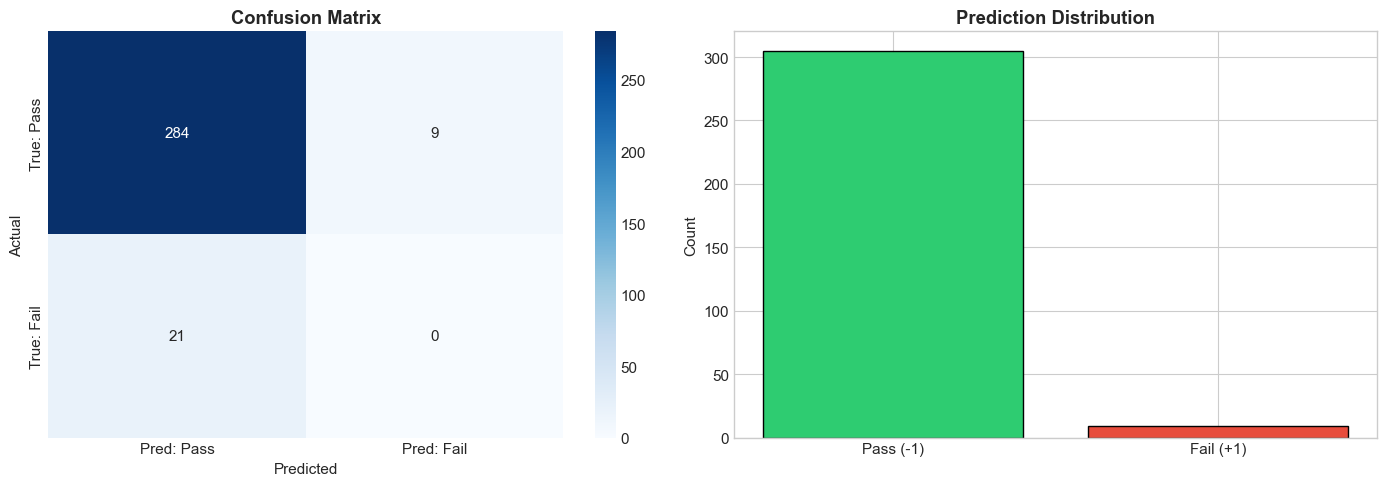

[그림 해석]
- 혼동 행렬: 대각선이 정확한 예측, 비대각선이 오분류
- 클래스 불균형으로 인해 Fail 예측이 어려울 수 있음


In [11]:
# 혼동 행렬 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 혼동 행렬 히트맵
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: Pass', 'Pred: Fail'],
            yticklabels=['True: Pass', 'True: Fail'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# 2. 예측 분포
pred_counts = pd.Series(y_pred_clf).value_counts()
axes[1].bar(['Pass (-1)', 'Fail (+1)'], 
            [pred_counts.get(-1, 0), pred_counts.get(1, 0)],
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_ylabel('Count')
axes[1].set_title('Prediction Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('classification_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("[그림 해석]")
print("- 혼동 행렬: 대각선이 정확한 예측, 비대각선이 오분류")
print("- 클래스 불균형으로 인해 Fail 예측이 어려울 수 있음")

In [13]:
X_test_scaled[:1]

array([[-3.99926758e-01,  1.64901946e-01, -7.79989082e-01,
        -6.92785884e-01, -4.04850516e-02, -1.54264558e-02,
        -4.81171164e-02, -5.41010972e-01, -2.97471800e-01,
        -9.71853745e-01, -5.32119038e-01,  7.88623031e-01,
         1.29151522e+00,  3.85852875e-01,  1.23367955e-01,
        -1.05782646e+00,  8.38107281e-01, -8.73184229e-02,
        -3.98274724e-01, -1.16578842e+00,  1.19537306e+00,
        -9.41715637e-02,  6.39556494e-01, -1.17652879e+00,
        -2.92644262e-01, -1.22572777e+00, -9.15173062e-01,
         1.64569302e+00,  6.25592851e-01,  1.86805069e+00,
         1.81253027e-02, -2.75068906e-01, -1.94938075e-01,
        -2.10350035e-01,  1.94930147e-01,  1.58887317e-02,
        -8.65971440e-02, -2.47814123e-01, -2.24215008e+00,
         8.61965384e-01,  1.28660567e+00, -1.63153135e+00,
         6.83194833e-01,  1.00129427e+00, -7.18291324e-01,
        -7.99646280e-01,  1.11829054e+00, -1.80704115e+00,
        -5.30582358e-01, -5.55034290e-01,  2.05520034e+0

In [14]:
len(X_test_scaled)

314

In [19]:
# 314개의 Feature를 임의로 막 만들어보기

new_data = np.random.random((1, 446))

In [20]:
new_data

array([[0.52802215, 0.56941096, 0.03308487, 0.0950607 , 0.21751415,
        0.84244455, 0.19104695, 0.76907024, 0.57132617, 0.19702407,
        0.38750794, 0.94731424, 0.10922644, 0.16558061, 0.20853168,
        0.97386222, 0.37075575, 0.1812159 , 0.59532296, 0.06723526,
        0.25217328, 0.50625159, 0.43097081, 0.97572263, 0.53100469,
        0.61781724, 0.03638851, 0.17388526, 0.24809965, 0.91840263,
        0.78588811, 0.4657641 , 0.35055556, 0.99371455, 0.75272277,
        0.91188803, 0.94177575, 0.91620793, 0.62068153, 0.47640536,
        0.03266927, 0.27527745, 0.80637656, 0.77862193, 0.62711756,
        0.62847894, 0.44038216, 0.87304921, 0.27511254, 0.02618391,
        0.59189177, 0.15763662, 0.84135209, 0.06578583, 0.05561552,
        0.60080441, 0.05236246, 0.44845245, 0.90776515, 0.19236238,
        0.00902485, 0.51409479, 0.51735959, 0.7676614 , 0.36932843,
        0.53714038, 0.4828052 , 0.05630136, 0.02170478, 0.43495763,
        0.03600714, 0.51497101, 0.00800547, 0.47

In [22]:
# 새로운 샘플에 대한 예측
print("=" * 60)
print("새로운 데이터 예측")
print("=" * 60)

new_samples = new_data
predictions = model_clf.predict(new_samples)

for i, pred in enumerate(predictions):
    actual = y_test[i]
    result = "Pass (정상)" if pred == -1 else "Fail (불량)"
    actual_str = "Pass" if actual == -1 else "Fail"
    match = "O" if pred == actual else "X"
    print(f"샘플 {i+1}: 예측={result}, 실제={actual_str}, 정답여부={match}")

새로운 데이터 예측
샘플 1: 예측=Pass (정상), 실제=Pass, 정답여부=O


### Predict 모델이 너무 복잡하기 때문에, 보다 간단한 예시로 하나 제시

In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1) (toy) 데이터 만들기: 중간고사, 기말고사 -> 합격/불합격
data = [
    {"midterm": 35, "final": 40, "label": "Fail"},
    {"midterm": 45, "final": 50, "label": "Fail"},
    {"midterm": 50, "final": 55, "label": "Fail"},
    {"midterm": 55, "final": 52, "label": "Fail"},
    {"midterm": 58, "final": 60, "label": "Pass"},
    {"midterm": 60, "final": 62, "label": "Pass"},
    {"midterm": 65, "final": 67, "label": "Pass"},
    {"midterm": 70, "final": 72, "label": "Pass"},
    {"midterm": 75, "final": 78, "label": "Pass"},
    {"midterm": 80, "final": 83, "label": "Pass"},
    {"midterm": 42, "final": 58, "label": "Fail"},
    {"midterm": 62, "final": 55, "label": "Pass"},
]
df = pd.DataFrame(data)

X = df[["midterm", "final"]]
y = df["label"]

# 2) 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [36]:
clf = DecisionTreeClassifier(max_depth=2, random_state=42)
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [37]:
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

In [38]:
print("=== 테스트 결과 ===")
print(f"Accuracy: {acc:.3f}")
print(classification_report(y_test, y_pred))

=== 테스트 결과 ===
Accuracy: 0.750
              precision    recall  f1-score   support

        Fail       1.00      0.50      0.67         2
        Pass       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



In [39]:
# 새 학생(새로운 입력)의 클래스 예측
new_students = pd.DataFrame([
    {"midterm": 73, "final": 69},
    {"midterm": 48, "final": 59},
    {"midterm": 90, "final": 85},
])

new_pred = clf.predict(new_students)
new_proba = clf.predict_proba(new_students)  # 클래스별 확률(선택)

print("=== 새 학생 예측 ===")
result = new_students.copy()
result["pred_label"] = new_pred
print(result)

print("\n=== 새 학생 예측 확률(클래스 순서: clf.classes_) ===")
print("classes_ =", clf.classes_)
print(new_proba)

=== 새 학생 예측 ===
   midterm  final pred_label
0       73     69       Pass
1       48     59       Fail
2       90     85       Pass

=== 새 학생 예측 확률(클래스 순서: clf.classes_) ===
classes_ = ['Fail' 'Pass']
[[0. 1.]
 [1. 0.]
 [0. 1.]]


## 회귀 실습: Steel Plates Faults 데이터

**회귀(Regression)**: 연속적인 숫자를 예측하는 문제

$$\text{출력: } y \in \mathbb{R} \quad \text{(실수)}$$

**예시 질문**:
- "생산량이 얼마인가요?" → 1,247개
- "불량률이 몇 %인가요?" → 3.5%
- "잔여 수명이 며칠인가요?" → 87일

In [23]:
# Steel Plates Faults 데이터 로드
steel_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00198/Faults.NNA"

steel_cols = ['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas', 
              'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity', 'Minimum_of_Luminosity',
              'Maximum_of_Luminosity', 'Length_of_Conveyer', 'TypeOfSteel_A300', 'TypeOfSteel_A400',
              'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index', 'Square_Index',
              'Outside_X_Index', 'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index',
              'LogOfAreas', 'Log_X_Index', 'Log_Y_Index', 'Orientation_Index',
              'Luminosity_Index', 'SigmoidOfAreas',
              'Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']

df_steel = pd.read_csv(steel_url, sep='\t', header=None, names=steel_cols)

print("=" * 60)
print("Steel Plates Faults 데이터 로드 완료")
print("=" * 60)
print(f"데이터 크기: {df_steel.shape}")
print(f"결측치: {df_steel.isna().sum().sum()}개")

Steel Plates Faults 데이터 로드 완료
데이터 크기: (1941, 34)
결측치: 0개


In [24]:
df_steel.head()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0


### 회귀 문제 설정

**타겟 설정**: 결함 면적(Pixels_Areas) 예측

In [25]:
# 특성과 타겟 정의
feature_cols = ['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum',
                'X_Perimeter', 'Y_Perimeter', 'Steel_Plate_Thickness',
                'Edges_Index', 'Empty_Index', 'Square_Index']

X_steel = df_steel[feature_cols]
y_steel = df_steel['Pixels_Areas']  # 결함 면적 (연속형 숫자)

print("=" * 60)
print("회귀 문제 설정")
print("=" * 60)
print(f"특성 (X): {len(feature_cols)}개 변수")
print(f"타겟 (y): Pixels_Areas (결함 면적)")
print(f"\n타겟 통계:")
print(f"  평균: {y_steel.mean():.2f}")
print(f"  표준편차: {y_steel.std():.2f}")
print(f"  최솟값: {y_steel.min():.2f}")
print(f"  최댓값: {y_steel.max():.2f}")

회귀 문제 설정
특성 (X): 10개 변수
타겟 (y): Pixels_Areas (결함 면적)

타겟 통계:
  평균: 1893.88
  표준편차: 5168.46
  최솟값: 2.00
  최댓값: 152655.00


In [26]:
# 학습/테스트 분리
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_steel, y_steel, test_size=0.2, random_state=42
)

# 스케일링
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print(f"학습 데이터: {len(X_train_reg)}개")
print(f"테스트 데이터: {len(X_test_reg)}개")

학습 데이터: 1552개
테스트 데이터: 389개


In [27]:
from sklearn.linear_model import LinearRegression

# 1. 모델 생성
model_reg = LinearRegression()

# 2. 학습 (fit)
print("모델 학습 중...")
model_reg.fit(X_train_reg_scaled, y_train_reg)
print("학습 완료!")

모델 학습 중...
학습 완료!


In [28]:
# 3. 예측 (predict)
y_pred_reg = model_reg.predict(X_test_reg_scaled)
print(f"\n예측 완료: {len(y_pred_reg)}개 샘플")


예측 완료: 389개 샘플


In [30]:
# 4. 평가 (score) - 회귀에서는 R² 점수
r2 = model_reg.score(X_test_reg_scaled, y_test_reg)
print(f"\nR² 점수: {r2:.4f}")


R² 점수: 0.9469


In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("=" * 60)
print("회귀 모델 상세 평가")
print("=" * 60)

# 다양한 평가 지표
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_reg, y_pred_reg)

print(f"\n[평가 지표]")
print(f"  R² (결정계수): {r2:.4f}")
print(f"  MSE (평균제곱오차): {mse:.2f}")
print(f"  RMSE (평균제곱근오차): {rmse:.2f}")
print(f"  MAE (평균절대오차): {mae:.2f}")

# 회귀 계수 확인
print(f"\n[회귀 계수]")
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model_reg.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_df)
print(f"\n절편 (Intercept): {model_reg.intercept_:.4f}")

회귀 모델 상세 평가

[평가 지표]
  R² (결정계수): 0.9469
  MSE (평균제곱오차): 761088.72
  RMSE (평균제곱근오차): 872.40
  MAE (평균절대오차): 531.03

[회귀 계수]
                 Feature   Coefficient
3              Y_Maximum -3.522233e+07
2              Y_Minimum  3.522201e+07
5            Y_Perimeter  1.100784e+04
4            X_Perimeter  3.006543e+03
0              X_Minimum -1.512392e+03
1              X_Maximum  1.307593e+03
8            Empty_Index -3.442600e+02
7            Edges_Index -1.374186e+02
6  Steel_Plate_Thickness -5.620124e+01
9           Square_Index -4.764722e+01

절편 (Intercept): 1915.9716


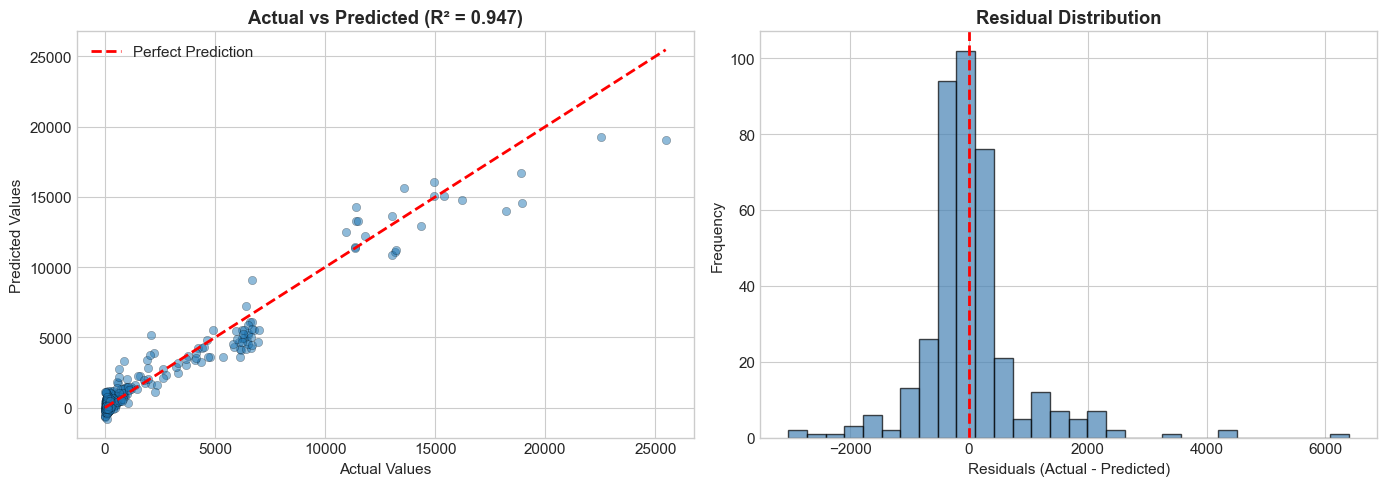

[그림 해석]
- 왼쪽: 점이 대각선에 가까울수록 예측 정확
- 오른쪽: 잔차가 0 주변에 정규분포하면 좋은 모델


In [32]:
# 회귀 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 실제값 vs 예측값
axes[0].scatter(y_test_reg, y_pred_reg, alpha=0.5, edgecolor='k', linewidth=0.3)
max_val = max(y_test_reg.max(), y_pred_reg.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title(f'Actual vs Predicted (R² = {r2:.3f})', fontweight='bold')
axes[0].legend()

# 2. 잔차 분포
residuals = y_test_reg - y_pred_reg
axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuals (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('regression_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("[그림 해석]")
print("- 왼쪽: 점이 대각선에 가까울수록 예측 정확")
print("- 오른쪽: 잔차가 0 주변에 정규분포하면 좋은 모델")

In [33]:
# 새로운 샘플에 대한 예측
print("=" * 60)
print("새로운 데이터 예측 (회귀)")
print("=" * 60)

# 테스트 데이터 중 첫 5개 샘플
new_samples_reg = X_test_reg_scaled[:5]
predictions_reg = model_reg.predict(new_samples_reg)

for i, pred in enumerate(predictions_reg):
    actual = y_test_reg.iloc[i]
    error = actual - pred
    error_pct = abs(error) / actual * 100 if actual != 0 else 0
    print(f"샘플 {i+1}: 예측={pred:.1f}, 실제={actual:.1f}, 오차={error:+.1f} ({error_pct:.1f}%)")

새로운 데이터 예측 (회귀)
샘플 1: 예측=344.7, 실제=1055.0, 오차=+710.3 (67.3%)
샘플 2: 예측=2230.7, 실제=1570.0, 오차=-660.7 (42.1%)
샘플 3: 예측=-48.9, 실제=89.0, 오차=+137.9 (154.9%)
샘플 4: 예측=327.8, 실제=78.0, 오차=-249.8 (320.2%)
샘플 5: 예측=266.1, 실제=51.0, 오차=-215.1 (421.7%)


## 분류 vs 회귀 비교 정리

| 구분    | 분류 (Classification)          | 회귀 (Regression)                  |
| ----- | ---------------------------- | -------------------------------- |
| 출력 형태 | 범주 (이산적)                     | 숫자 (연속적)                         |
| 예시 질문 | “불량인가요?”                     | “얼마나?”                           |
| 사용 모델 | DecisionTree<br>RandomForest | LinearRegression<br>Ridge, Lasso |
| 평가 지표 | Accuracy, F1                 | R², RMSE, MAE                    |
| 이번 결과 | 정확도 `{accuracy:.1%}`         | R² `{r2:.4f}`                    |

## 이번 실습 요약

| 항목         | 내용                                 |
| ---------- | ---------------------------------- |
| **데이터 분리** | `train_test_split`으로 학습/테스트 분리     |
| **분류 모델**  | `DecisionTreeClassifier`로 불량 여부 예측 |
| **회귀 모델**  | `LinearRegression`으로 결함 면적 예측      |
| **평가 지표**  | 분류: Accuracy, 회귀: R²               |
| **핵심 패턴**  | `fit → predict → score`            |

## 현재 모델과 추후 차시 연계

[분류 모델 한계]
  - 정확도가 90% 가량이지만 클래스 불균형 문제
  - Fail 클래스 재현율이 낮을 수 있음
  → 13차시: 의사결정나무 깊이 학습, 과적합 방지

[회귀 모델 한계]
  - 비선형 관계 포착 어려움
  → 이후 차시: 다양한 회귀 모델 학습

[공통 개선 방향]
  - 특성 공학 (Feature Engineering)
  - 하이퍼파라미터 튜닝
  - 앙상블 모델 (Random Forest, XGBoost)
